# SKATER Regional Clustering

Spatially-constrained regionalization using **SKATER** (Spatial K-means Clustering And Regionalization via spanning-tree edge removal — `spopt.region.Skater`).  SKATER builds a minimum spanning tree on the geographic site graph, then prunes edges greedily to minimize within-region feature heterogeneity.  Unlike Ward + k-NN, it accepts a hard `floor` that prevents tiny isolated regions.

Two analyses:

| # | Features | Interpretation |
|---|----------|----------------|
| 1 | `lp3_scale`, `lp3_skew` | Shape of the flood frequency curve |
| 2 | `log10(1/aep)` for action / flood / moderate / major thresholds | How rare local flood impacts are |


See SKATER description: https://lanselin.github.io/introbook_vol2/skater.html


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path
from shapely.geometry import Point
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from scipy.sparse.csgraph import connected_components

import libpysal
from spopt.region import Skater

/home/ryan/miniforge3/envs/hydro/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Configuration

In [2]:
DATA_DIR   = Path("/home/ryan/data/flood_hazard")
GAGES2_DIR = Path("/home/ryan/data/usgs/GAGES_2/basinchar_and_report_sept_2011/spreadsheets-in-csv-format")
OUT_DIR    = Path(".")

K_NEIGHBORS       = 7    # k-NN for spatial weights
FLOOR             = 30   # minimum sites per region
N_CLUSTERS_LP3    = 8    # tune via silhouette sweep
N_CLUSTERS_AEP    = 8
MAX_DISTURB_INDEX = 15
WINSOR            = 0.02
SAVEFIG           = False

CONUS_EXTENT = [-125, -66, 24, 50]

def make_conus_ax(fig, pos=111, title=''):
    subplot_args = pos if isinstance(pos, tuple) else (pos,)
    ax = fig.add_subplot(*subplot_args, projection=ccrs.AlbersEqualArea(
        central_longitude=-96, central_latitude=37.5))
    ax.set_extent(CONUS_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='#c8e0f0', zorder=0)
    ax.add_feature(cfeature.LAKES,     facecolor='#c8e0f0', zorder=1, alpha=0.6)
    ax.add_feature(cfeature.STATES,    linewidth=0.4, zorder=2, edgecolor='gray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.6, zorder=3)
    if title:
        ax.set_title(title)
    return ax

## Load shared data

In [3]:
ffa  = pd.read_parquet(DATA_DIR / "ffa" / "flood_frequency.parquet")
meta = pd.read_parquet(DATA_DIR / "metadata" / "site_info.parquet")[["site_no", "latitude", "longitude"]]

gages2 = pd.read_csv(GAGES2_DIR / "conterm_bas_classif.txt", encoding="latin1")
gages2["site_no"] = gages2["STAID"].astype(str).str.zfill(8)

print(f"FFA records : {len(ffa):,}")
print(f"Site meta   : {len(meta):,}")
print(f"GAGES-2     : {len(gages2):,}")

FFA records : 3,336
Site meta   : 9,071
GAGES-2     : 9,067


---
# Analysis 1: LP3-based SKATER

Features: **`lp3_scale`** and **`lp3_skew`** — shape of the LP3 flood frequency curve.  
Same site filtering and winsorization used in `ffa_clustering.ipynb`; `RobustScaler` replaces `StandardScaler` for outlier robustness.

In [4]:
df1 = (
    ffa[ffa.record_ok & ffa.lp3_scale.notna() & ffa.lp3_skew.notna()]
    [["site_no", "lp3_scale", "lp3_skew"]]
    .merge(meta, on="site_no")
    .merge(gages2[["site_no", "HYDRO_DISTURB_INDX"]], on="site_no", how="left")
)
df1 = df1[
    df1.HYDRO_DISTURB_INDX.notna() & (df1.HYDRO_DISTURB_INDX <= MAX_DISTURB_INDEX)
].reset_index(drop=True)

print(f"LP3 analysis: {len(df1):,} sites")

LP3 analysis: 1,362 sites


## Winsorize and scale features

lp3_scale: clipped [0.1269, 2.3244]  (raw [0.0804, 7.0555])
lp3_skew: clipped [-1.8763, 1.1735]  (raw [-5.1824, 6.0610])


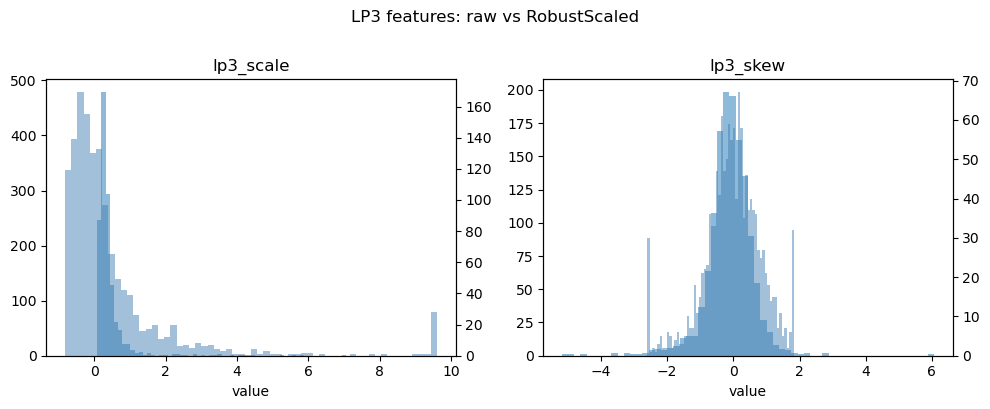

In [5]:
LP3_FEATS = ["lp3_scale", "lp3_skew"]
LP3_SCALED = [f + "_s" for f in LP3_FEATS]

df1_clip = df1.copy()
for col in LP3_FEATS:
    lo, hi = df1[col].quantile([WINSOR, 1 - WINSOR])
    df1_clip[col] = df1[col].clip(lo, hi)
    print(f"{col}: clipped [{lo:.4f}, {hi:.4f}]  (raw [{df1[col].min():.4f}, {df1[col].max():.4f}])")

scaler1 = RobustScaler()
X1 = scaler1.fit_transform(df1_clip[LP3_FEATS])
for i, col in enumerate(LP3_SCALED):
    df1[col] = X1[:, i]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (raw, scaled) in enumerate(zip(LP3_FEATS, LP3_SCALED)):
    axes[i].hist(df1[raw], bins=60, alpha=0.5, label='raw', edgecolor='none')
    ax2 = axes[i].twinx()
    ax2.hist(df1[scaled], bins=60, alpha=0.5, color='steelblue', label='scaled', edgecolor='none')
    axes[i].set_title(raw)
    axes[i].set_xlabel('value')
plt.suptitle('LP3 features: raw vs RobustScaled', y=1.01)
plt.tight_layout()
plt.show()

## Build spatial weights (libpysal KNN)

In [6]:
gdf1 = gpd.GeoDataFrame(
    df1,
    geometry=[Point(lon, lat) for lon, lat in zip(df1.longitude, df1.latitude)]
)

w1 = libpysal.weights.KNN.from_dataframe(gdf1, k=K_NEIGHBORS)

n_comp, _ = connected_components(w1.sparse, directed=False)
print(f"Sites: {len(gdf1):,}  |  Edges: {w1.sparse.nnz // 2:,}  |  k={K_NEIGHBORS}")
print(f"Connected components: {n_comp}  {'OK' if n_comp == 1 else 'WARNING — increase K_NEIGHBORS'}")

Sites: 1,362  |  Edges: 4,767  |  k=7
Connected components: 1  OK


## SKATER clustering — LP3

In [7]:
model1 = Skater(gdf1, w1, attrs_name=LP3_SCALED, n_clusters=N_CLUSTERS_LP3, floor=FLOOR)
model1.solve()

df1["cluster"] = model1.labels_ + 1
gdf1["cluster"] = df1["cluster"]

sizes1 = df1["cluster"].value_counts().sort_index()
print(f"N_CLUSTERS={N_CLUSTERS_LP3}  |  floor={FLOOR}")
print(sizes1.to_string())
print(f"\nMin: {sizes1.min()}  |  Max: {sizes1.max()}  |  Ratio: {sizes1.max()/sizes1.min():.1f}x")

N_CLUSTERS=8  |  floor=30
cluster
1    354
2    262
3     42
4    270
5    263
6     37
7     56
8     78

Min: 37  |  Max: 354  |  Ratio: 9.6x


## Silhouette sweep — LP3

Sweep `n_clusters` to find a natural elbow.  Each model is run with `floor=FLOOR` to prevent tiny regions.

In [8]:
# sil_k_range = range(2, 15)
# sil_scores1 = []

# for k in sil_k_range:
#     m = Skater(gdf1, w1, attrs_name=LP3_SCALED, n_clusters=k, floor=FLOOR)
#     m.solve()
#     sil_scores1.append(silhouette_score(X1, m.labels_))
#     print(f"k={k:2d}  sil={sil_scores1[-1]:.4f}")

# best_k1 = list(sil_k_range)[np.argmax(sil_scores1)]

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(list(sil_k_range), sil_scores1, marker='o')
# ax.axvline(best_k1, color='red', linestyle='--', label=f'best k={best_k1}')
# ax.axvline(N_CLUSTERS_LP3, color='gray', linestyle=':', label=f'current N_CLUSTERS={N_CLUSTERS_LP3}')
# ax.set_xlabel('Number of clusters')
# ax.set_ylabel('Mean silhouette score')
# ax.set_title('Silhouette scores — LP3 SKATER')
# ax.legend()
# plt.tight_layout()
# plt.show()

# print(f"Best k by silhouette: {best_k1}  (score={max(sil_scores1):.4f})")

## Cluster map — LP3

/tmp/ipykernel_3895568/352561938.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('tab20', N_CLUSTERS_LP3)


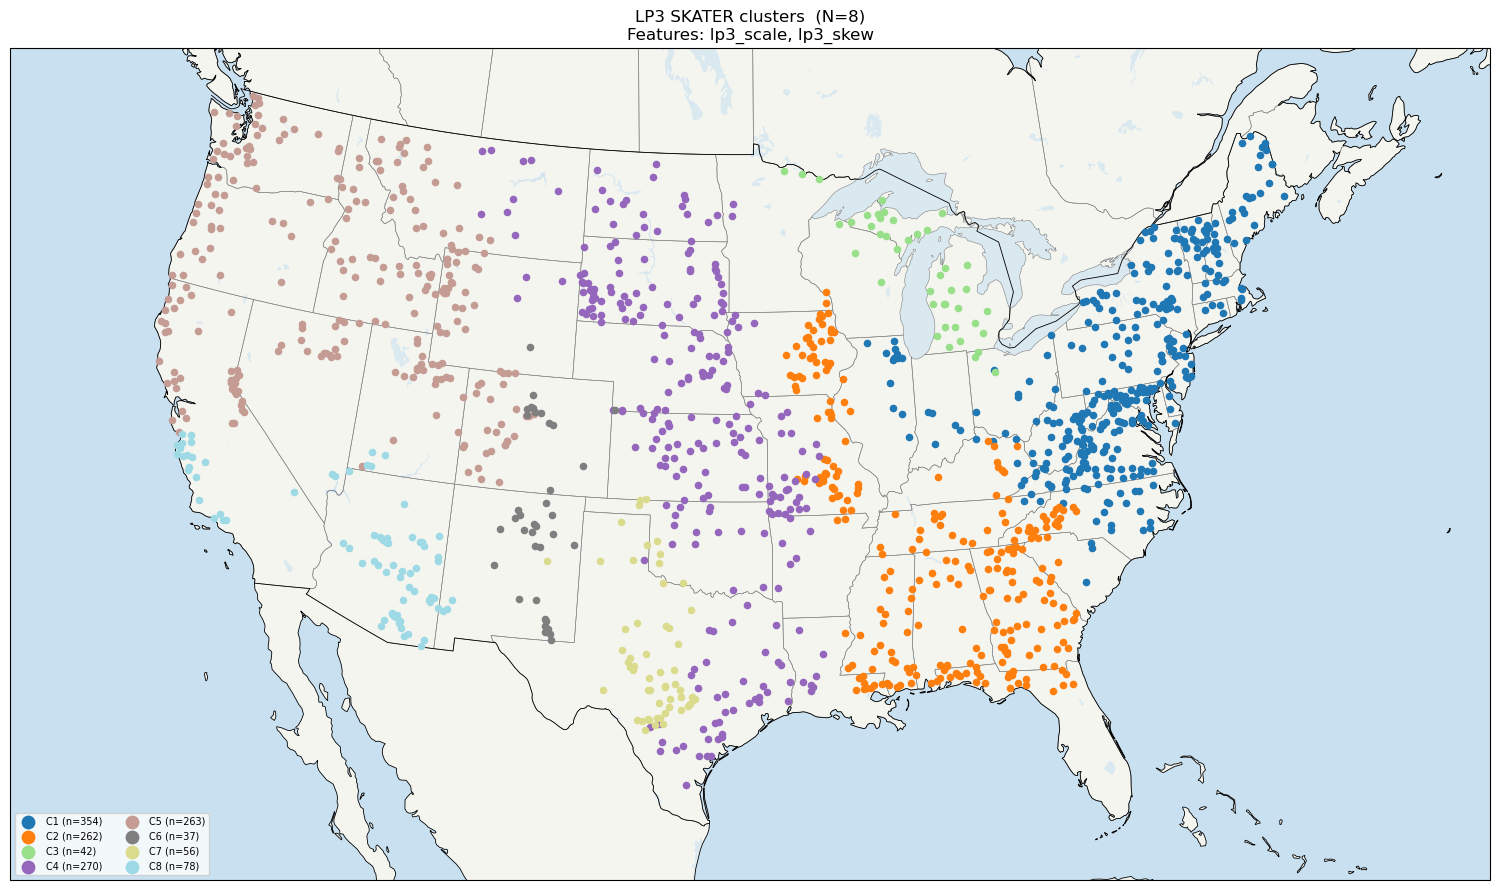

In [9]:
cmap1 = cm.get_cmap('tab20', N_CLUSTERS_LP3)

fig = plt.figure(figsize=(16, 9))
ax  = make_conus_ax(fig, title=(
    f'LP3 SKATER clusters  (N={N_CLUSTERS_LP3})\n'
    f'Features: lp3_scale, lp3_skew'
))

for cl in sorted(df1["cluster"].unique()):
    idx = df1["cluster"] == cl
    ax.scatter(
        df1.loc[idx, "longitude"], df1.loc[idx, "latitude"],
        s=20, color=cmap1(cl - 1), zorder=4,
        transform=ccrs.PlateCarree(),
        label=f'C{cl} (n={idx.sum():,})'
    )

ax.legend(markerscale=2, fontsize=7, ncol=2, loc='lower left', framealpha=0.8)
plt.tight_layout()
if SAVEFIG:
    plt.savefig(OUT_DIR / f'skater_lp3_n{N_CLUSTERS_LP3}_k{K_NEIGHBORS}.png', dpi=300, bbox_inches='tight')
plt.show()

## Cluster profiles — LP3

In [10]:
profile1 = (
    df1.groupby("cluster")[["lp3_scale", "lp3_skew"]]
    .agg(["mean", "std", "count"])
)
profile1.columns = ["_".join(c) for c in profile1.columns]
print(profile1.to_string())

         lp3_scale_mean  lp3_scale_std  lp3_scale_count  lp3_skew_mean  lp3_skew_std  lp3_skew_count
cluster                                                                                             
1              0.248832       0.101035              354       0.264339      0.499134             354
2              0.312368       0.178456              262      -0.116666      0.502823             262
3              0.175339       0.033254               42      -0.074047      0.367313              42
4              0.672245       0.799336              270      -0.338564      0.771790             270
5              0.348810       0.446134              263      -0.189532      0.833665             263
6              0.696315       0.586692               37      -0.345762      1.032873              37
7              1.172840       1.215281               56      -0.632517      0.727617              56
8              0.600592       0.474594               78      -0.404903      0.617990       

## Save LP3 cluster outputs

In [11]:
# out_path = OUT_DIR / f"site_regions_skater_lp3_{N_CLUSTERS_LP3}.csv"
# df1[["site_no", "cluster", "latitude", "longitude", "lp3_scale", "lp3_skew"]].to_csv(out_path, index=False)
# print(f"Saved: {out_path}")

---
# Analysis 2: AEP Threshold SKATER

Features: **log₁₀ return period** for each of the four NWS flood threshold levels — action, flood, moderate, major.  
A high return period means the threshold is rarely exceeded (low-hazard site); a low return period means it is frequently exceeded (high-hazard site).

Only sites with **all four** threshold AEP values are included.

In [12]:
AEP_COLS = ["action_aep", "flood_aep", "moderate_aep", "major_aep"]

df2 = (
    ffa[ffa.record_ok & ~ffa.degenerate_fit]
    [["site_no"] + AEP_COLS]
    .dropna(subset=AEP_COLS)
    .merge(meta, on="site_no")
    .merge(gages2[["site_no", "HYDRO_DISTURB_INDX"]], on="site_no", how="left")
)
df2 = df2[
    df2.HYDRO_DISTURB_INDX.notna() & (df2.HYDRO_DISTURB_INDX <= MAX_DISTURB_INDEX)
].reset_index(drop=True)

print(f"AEP analysis: {len(df2):,} sites")
print("\nAEP value ranges:")
print(df2[AEP_COLS].describe().loc[["min", "50%", "max"]].to_string())

AEP analysis: 1,050 sites

AEP value ranges:
     action_aep  flood_aep  moderate_aep  major_aep
min    0.000000   0.000000      0.000000   0.000000
50%    0.537599   0.263483      0.088329   0.030405
max    0.999999   0.999910      0.996956   0.996956


## Transform and scale features

AEP → `log10(1/AEP)` = log₁₀ of the return period in years.  This linearises the feature space (5-yr → 0.70, 10-yr → 1.0, 100-yr → 2.0) and avoids the right-skew of raw AEP values.

Log10 return period ranges (raw):
        action_rp  flood_rp  moderate_rp  major_rp
min  2.194934e-07  0.000039     0.001324  0.001324
50%  2.695417e-01  0.579248     1.053896  1.517048
max  6.000000e+00  6.000000     6.000000  6.000000
action_rp: clipped [0.00, 1.97]  (42 sites clipped)
flood_rp: clipped [0.03, 2.38]  (42 sites clipped)
moderate_rp: clipped [0.19, 4.37]  (42 sites clipped)
major_rp: clipped [0.49, 6.00]  (21 sites clipped)


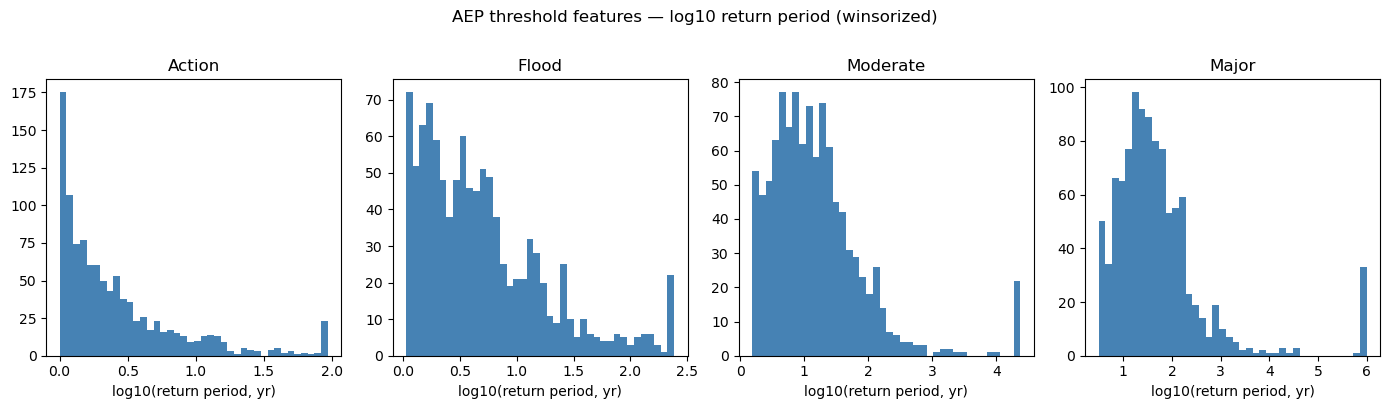

In [13]:
RP_FEATS  = ["action_rp", "flood_rp", "moderate_rp", "major_rp"]
RP_SCALED = [f + "_s" for f in RP_FEATS]

for aep_col, rp_col in zip(AEP_COLS, RP_FEATS):
    df2[rp_col] = np.log10(1.0 / df2[aep_col].clip(lower=1e-6))

print("Log10 return period ranges (raw):")
print(df2[RP_FEATS].describe().loc[["min", "50%", "max"]].to_string())

# Winsorize before scaling — same approach as LP3 section
df2_clip = df2.copy()
for col in RP_FEATS:
    lo, hi = df2[col].quantile([WINSOR, 1 - WINSOR])
    n_clipped = ((df2[col] < lo) | (df2[col] > hi)).sum()
    df2_clip[col] = df2[col].clip(lo, hi)
    print(f"{col}: clipped [{lo:.2f}, {hi:.2f}]  ({n_clipped} sites clipped)")

scaler2 = RobustScaler()
X2 = scaler2.fit_transform(df2_clip[RP_FEATS])
for i, col in enumerate(RP_SCALED):
    df2[col] = X2[:, i]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, (rp, label) in enumerate(zip(RP_FEATS, ["Action", "Flood", "Moderate", "Major"])):
    axes[i].hist(df2_clip[rp], bins=40, edgecolor="none", color="steelblue")
    axes[i].set_title(label)
    axes[i].set_xlabel("log10(return period, yr)")
plt.suptitle("AEP threshold features — log10 return period (winsorized)", y=1.01)
plt.tight_layout()
plt.show()

## Build spatial weights

In [14]:
gdf2 = gpd.GeoDataFrame(
    df2,
    geometry=[Point(lon, lat) for lon, lat in zip(df2.longitude, df2.latitude)]
)

w2 = libpysal.weights.KNN.from_dataframe(gdf2, k=K_NEIGHBORS)

n_comp2, _ = connected_components(w2.sparse, directed=False)
print(f"Sites: {len(gdf2):,}  |  Edges: {w2.sparse.nnz // 2:,}  |  k={K_NEIGHBORS}")
print(f"Connected components: {n_comp2}  {'OK' if n_comp2 == 1 else 'WARNING — increase K_NEIGHBORS'}")

Sites: 1,050  |  Edges: 3,675  |  k=7
Connected components: 1  OK


## SKATER clustering — AEP thresholds

In [15]:
model2 = Skater(gdf2, w2, attrs_name=RP_SCALED, n_clusters=N_CLUSTERS_AEP, floor=FLOOR)
model2.solve()

df2["cluster"] = model2.labels_ + 1
gdf2["cluster"] = df2["cluster"]

sizes2 = df2["cluster"].value_counts().sort_index()
print(f"N_CLUSTERS={N_CLUSTERS_AEP}  |  floor={FLOOR}")
print(sizes2.to_string())
print(f"\nMin: {sizes2.min()}  |  Max: {sizes2.max()}  |  Ratio: {sizes2.max()/sizes2.min():.1f}x")

N_CLUSTERS=8  |  floor=30
cluster
1    329
2     36
3    280
4     97
5     66
6    101
7     38
8    103

Min: 36  |  Max: 329  |  Ratio: 9.1x


## Silhouette sweep — AEP thresholds

In [16]:
# sil_k_range = range(2, 15)
# sil_scores2 = []

# for k in sil_k_range:
#     m = Skater(gdf2, w2, attrs_name=RP_SCALED, n_clusters=k, floor=FLOOR)
#     m.solve()
#     sil_scores2.append(silhouette_score(X2, m.labels_))
#     print(f"k={k:2d}  sil={sil_scores2[-1]:.4f}")

# best_k2 = list(sil_k_range)[np.argmax(sil_scores2)]

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(list(sil_k_range), sil_scores2, marker='o', color='darkorange')
# ax.axvline(best_k2, color='red', linestyle='--', label=f'best k={best_k2}')
# ax.axvline(N_CLUSTERS_AEP, color='gray', linestyle=':', label=f'current N_CLUSTERS={N_CLUSTERS_AEP}')
# ax.set_xlabel('Number of clusters')
# ax.set_ylabel('Mean silhouette score')
# ax.set_title('Silhouette scores — AEP threshold SKATER')
# ax.legend()
# plt.tight_layout()
# plt.show()

# print(f"Best k by silhouette: {best_k2}  (score={max(sil_scores2):.4f})")

## Cluster map — AEP thresholds

/tmp/ipykernel_3895568/3077272211.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('tab20', N_CLUSTERS_AEP)


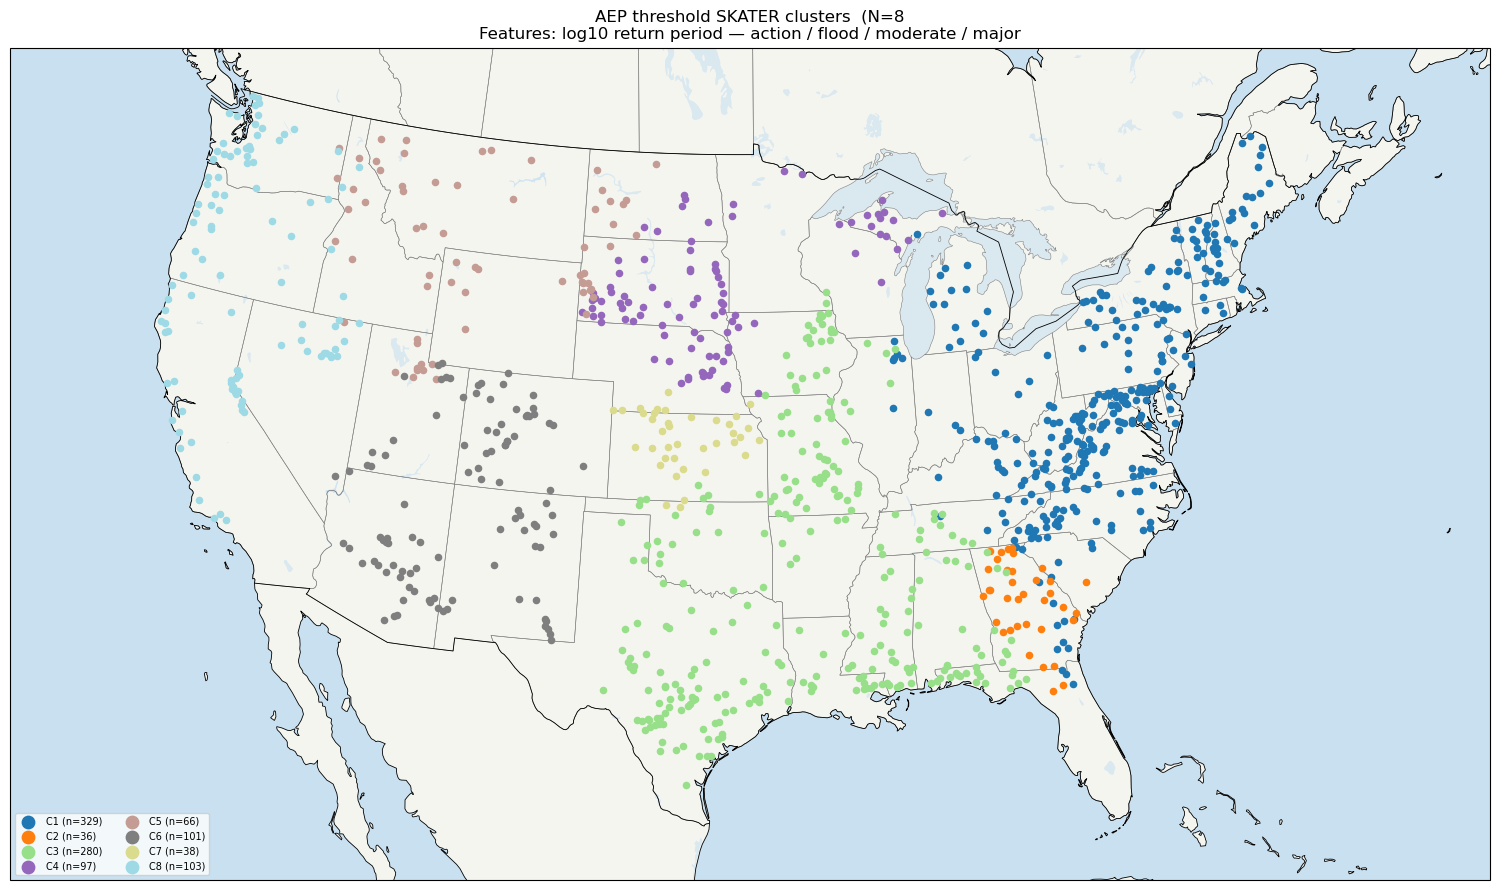

In [17]:
cmap2 = cm.get_cmap('tab20', N_CLUSTERS_AEP)

fig = plt.figure(figsize=(16, 9))
ax  = make_conus_ax(fig, title=(
    f'AEP threshold SKATER clusters  (N={N_CLUSTERS_AEP}\n'
    f'Features: log10 return period — action / flood / moderate / major'
))

for cl in sorted(df2["cluster"].unique()):
    idx = df2["cluster"] == cl
    ax.scatter(
        df2.loc[idx, "longitude"], df2.loc[idx, "latitude"],
        s=20, color=cmap2(cl - 1), zorder=4,
        transform=ccrs.PlateCarree(),
        label=f'C{cl} (n={idx.sum():,})'
    )

ax.legend(markerscale=2, fontsize=7, ncol=2, loc='lower left', framealpha=0.8)
plt.tight_layout()
if SAVEFIG:
    plt.savefig(OUT_DIR / f'skater_aep_n{N_CLUSTERS_AEP}_k{K_NEIGHBORS}.png', dpi=300, bbox_inches='tight')
plt.show()

## Cluster profiles — AEP thresholds

Return periods reported back in years (median per cluster).

In [18]:
profile2 = df2.groupby("cluster")[RP_FEATS].agg(["median", "std", "count"])
profile2.columns = ["_".join(c) for c in profile2.columns]

# Also show in original return period years for interpretability
rp_medians = df2.groupby("cluster")[RP_FEATS].median()
rp_years   = 10 ** rp_medians
rp_years.columns = [c.replace("_rp", "_yr") for c in rp_years.columns]
print("Median return period (years) per cluster:")
print(rp_years.round(1).to_string())

print()
print("Full profile (log10 return period):")
print(profile2.to_string())

Median return period (years) per cluster:
         action_yr  flood_yr  moderate_yr  major_yr
cluster                                            
1              1.6       3.6         12.9      48.8
2              2.7       8.9         35.6      94.9
3              1.3       1.8          3.9      15.1
4              3.1       5.3         17.6      37.4
5              5.2      13.8         40.5     122.7
6              4.8      12.5         21.3      32.2
7              2.4       3.5          9.6      23.9
8              2.4       4.6         12.8      31.7

Full profile (log10 return period):
         action_rp_median  action_rp_std  action_rp_count  flood_rp_median  flood_rp_std  flood_rp_count  moderate_rp_median  moderate_rp_std  moderate_rp_count  major_rp_median  major_rp_std  major_rp_count
cluster                                                                                                                                                                                          

## Save AEP cluster outputs

In [19]:
# out_path = OUT_DIR / f"site_regions_skater_aep_{N_CLUSTERS_AEP}.csv"
# df2[["site_no", "cluster", "latitude", "longitude"] + AEP_COLS].to_csv(out_path, index=False)
# print(f"Saved: {out_path}")

---
# Comparison: LP3 vs AEP clusters

Sites present in both analyses are plotted side-by-side.

In [20]:
common = set(df1.site_no) & set(df2.site_no)
print(f"Sites in LP3 analysis  : {len(df1):,}")
print(f"Sites in AEP analysis  : {len(df2):,}")
print(f"Sites in both          : {len(common):,}")

print("\nLP3 cluster sizes:")
print(df1["cluster"].value_counts().sort_index().to_string())

print("\nAEP cluster sizes:")
print(df2["cluster"].value_counts().sort_index().to_string())

Sites in LP3 analysis  : 1,362
Sites in AEP analysis  : 1,050
Sites in both          : 1,050

LP3 cluster sizes:
cluster
1    354
2    262
3     42
4    270
5    263
6     37
7     56
8     78

AEP cluster sizes:
cluster
1    329
2     36
3    280
4     97
5     66
6    101
7     38
8    103


/tmp/ipykernel_3895568/3003765320.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_c1 = cm.get_cmap('tab20', n_cl1)
/tmp/ipykernel_3895568/3003765320.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_c2 = cm.get_cmap('tab20', n_cl2)


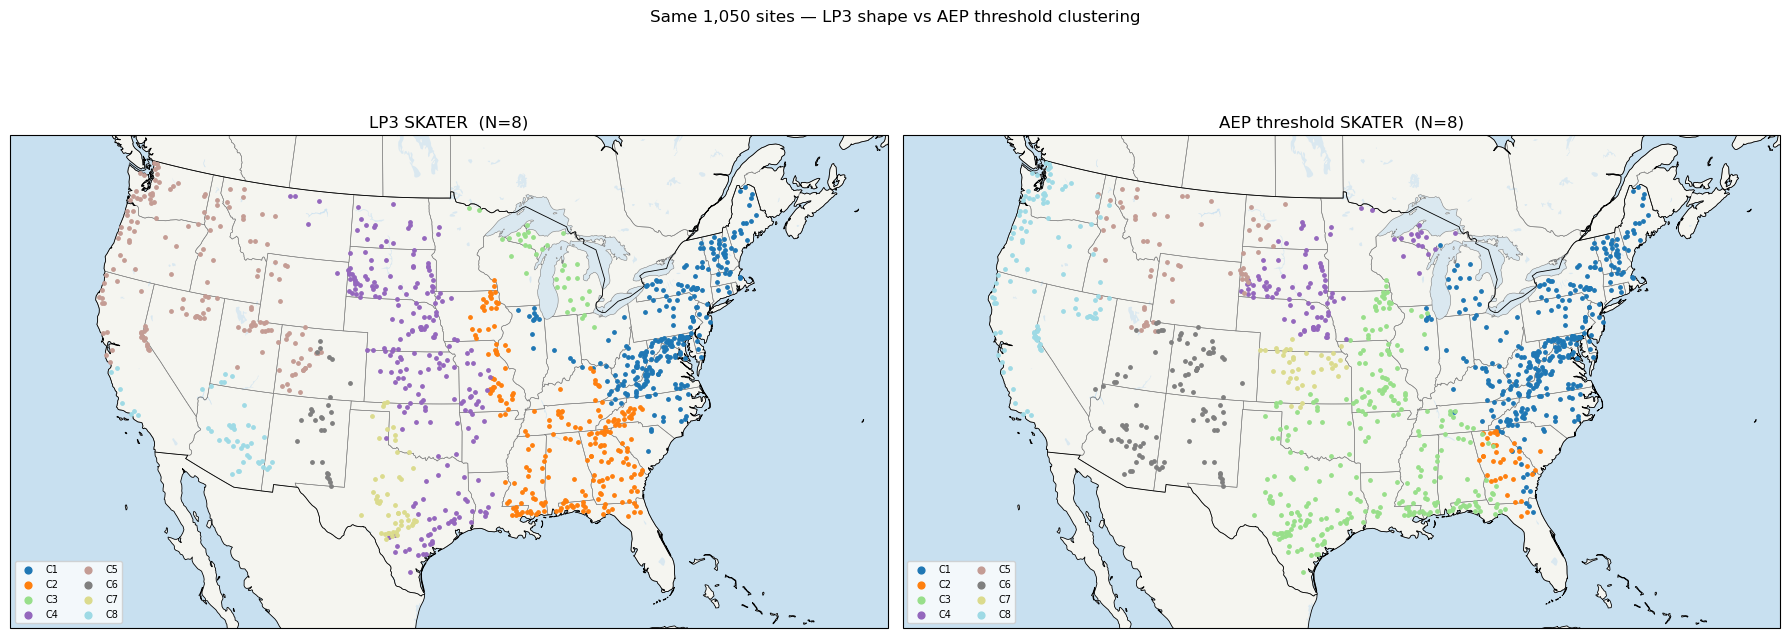

In [21]:
df1_cmp = df1[df1.site_no.isin(common)].copy()
df2_cmp = df2[df2.site_no.isin(common)].copy()

n_cl1 = df1_cmp["cluster"].nunique()
n_cl2 = df2_cmp["cluster"].nunique()
cmap_c1 = cm.get_cmap('tab20', n_cl1)
cmap_c2 = cm.get_cmap('tab20', n_cl2)

fig = plt.figure(figsize=(18, 7))

ax1 = make_conus_ax(fig, pos=(1, 2, 1), title=f'LP3 SKATER  (N={N_CLUSTERS_LP3})')
for cl in sorted(df1_cmp["cluster"].unique()):
    idx = df1_cmp["cluster"] == cl
    ax1.scatter(
        df1_cmp.loc[idx, "longitude"], df1_cmp.loc[idx, "latitude"],
        s=6, color=cmap_c1(cl - 1), zorder=4,
        transform=ccrs.PlateCarree(), label=f'C{cl}'
    )
ax1.legend(markerscale=2, fontsize=7, ncol=2, loc='lower left', framealpha=0.8)

ax2 = make_conus_ax(fig, pos=(1, 2, 2), title=f'AEP threshold SKATER  (N={N_CLUSTERS_AEP})')
for cl in sorted(df2_cmp["cluster"].unique()):
    idx = df2_cmp["cluster"] == cl
    ax2.scatter(
        df2_cmp.loc[idx, "longitude"], df2_cmp.loc[idx, "latitude"],
        s=6, color=cmap_c2(cl - 1), zorder=4,
        transform=ccrs.PlateCarree(), label=f'C{cl}'
    )
ax2.legend(markerscale=2, fontsize=7, ncol=2, loc='lower left', framealpha=0.8)

plt.suptitle(f'Same {len(common):,} sites — LP3 shape vs AEP threshold clustering', y=1.01)
plt.tight_layout()
if SAVEFIG:
    plt.savefig(OUT_DIR / f'skater_comparison_k{K_NEIGHBORS}.png', dpi=300, bbox_inches='tight')
plt.show()

Shared sites : 1,050
ARI          : 0.471   (0 = random, 1 = perfect)
NMI          : 0.609   (0 = independent, 1 = identical)

Contingency table (site counts):
AEP cluster    1   2    3   4   5   6   7   8
LP3 cluster                                  
1            262   1    4   0   0   0   0   0
2             49  35  138   0   0   0   0   0
3             18   0    0  18   0   0   0   0
4              0   0   88  79  26   0  38   0
5              0   0    0   0  40  34   0  96
6              0   0    0   0   0  28   0   0
7              0   0   50   0   0   0   0   0
8              0   0    0   0   0  39   0   7


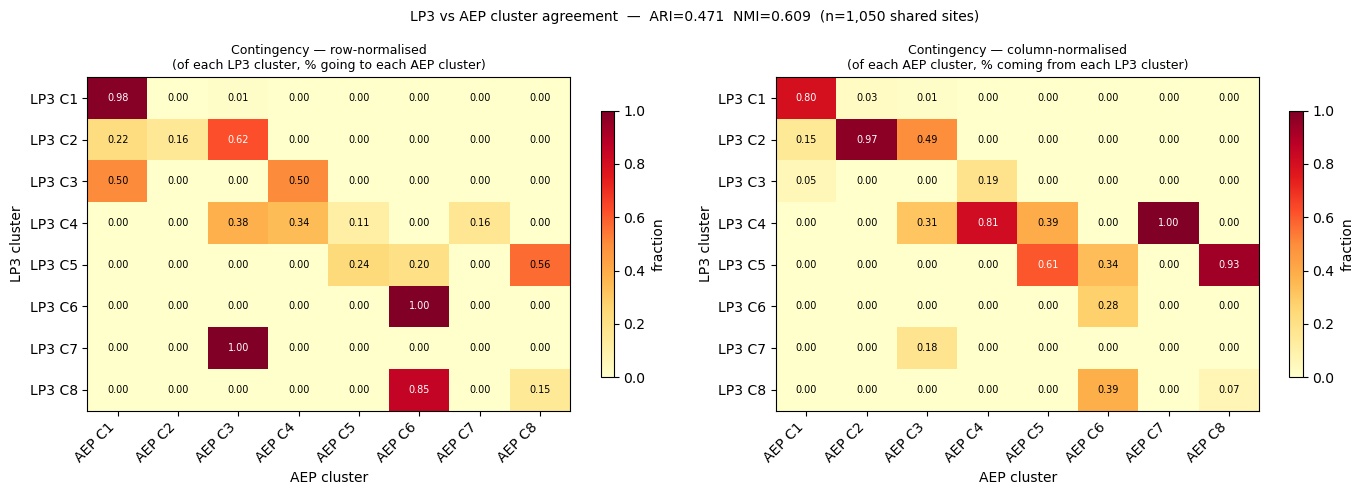

In [22]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Align on the intersection of sites
merged = (
    df1[["site_no", "cluster"]].rename(columns={"cluster": "cl_lp3"})
    .merge(df2[["site_no", "cluster"]].rename(columns={"cluster": "cl_aep"}), on="site_no")
)

ari = adjusted_rand_score(merged.cl_lp3, merged.cl_aep)
nmi = normalized_mutual_info_score(merged.cl_lp3, merged.cl_aep)
print(f"Shared sites : {len(merged):,}")
print(f"ARI          : {ari:.3f}   (0 = random, 1 = perfect)")
print(f"NMI          : {nmi:.3f}   (0 = independent, 1 = identical)")

ct = pd.crosstab(
    merged.cl_lp3, merged.cl_aep,
    rownames=["LP3 cluster"], colnames=["AEP cluster"]
)
print("\nContingency table (site counts):")
print(ct.to_string())

# ── Normalised heatmaps ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, norm_axis, title_suffix in zip(
    axes,
    [1, 0],
    ["row-normalised\n(of each LP3 cluster, % going to each AEP cluster)",
     "column-normalised\n(of each AEP cluster, % coming from each LP3 cluster)"]
):
    ct_norm = ct.div(ct.sum(axis=norm_axis), axis=1 - norm_axis)
    im = ax.imshow(ct_norm.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels([f"AEP C{c}" for c in ct.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels([f"LP3 C{r}" for r in ct.index])
    ax.set_xlabel("AEP cluster")
    ax.set_ylabel("LP3 cluster")
    ax.set_title(f"Contingency — {title_suffix}", fontsize=9)

    for i in range(len(ct.index)):
        for j in range(len(ct.columns)):
            val = ct_norm.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if val < 0.6 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8, label="fraction")

plt.suptitle(
    f"LP3 vs AEP cluster agreement  —  ARI={ari:.3f}  NMI={nmi:.3f}  (n={len(merged):,} shared sites)",
    fontsize=10
)
plt.tight_layout()
plt.show()

### Cluster assignment agreement

Maybe sites that agree means that the "local" flood thresholds match the LP3?

Optimal LP3 → AEP label mapping:
  LP3 C1 → AEP C1  (262/267 agree,  98%)
  LP3 C2 → AEP C3  (138/222 agree,  62%)
  LP3 C3 → AEP C2  (0/36 agree,  0%)
  LP3 C4 → AEP C4  (79/231 agree,  34%)
  LP3 C5 → AEP C8  (96/170 agree,  56%)
  LP3 C6 → AEP C7  (0/28 agree,  0%)
  LP3 C7 → AEP C5  (0/50 agree,  0%)
  LP3 C8 → AEP C6  (39/46 agree,  85%)

Overall agreement: 614/1,050  (58.5%)


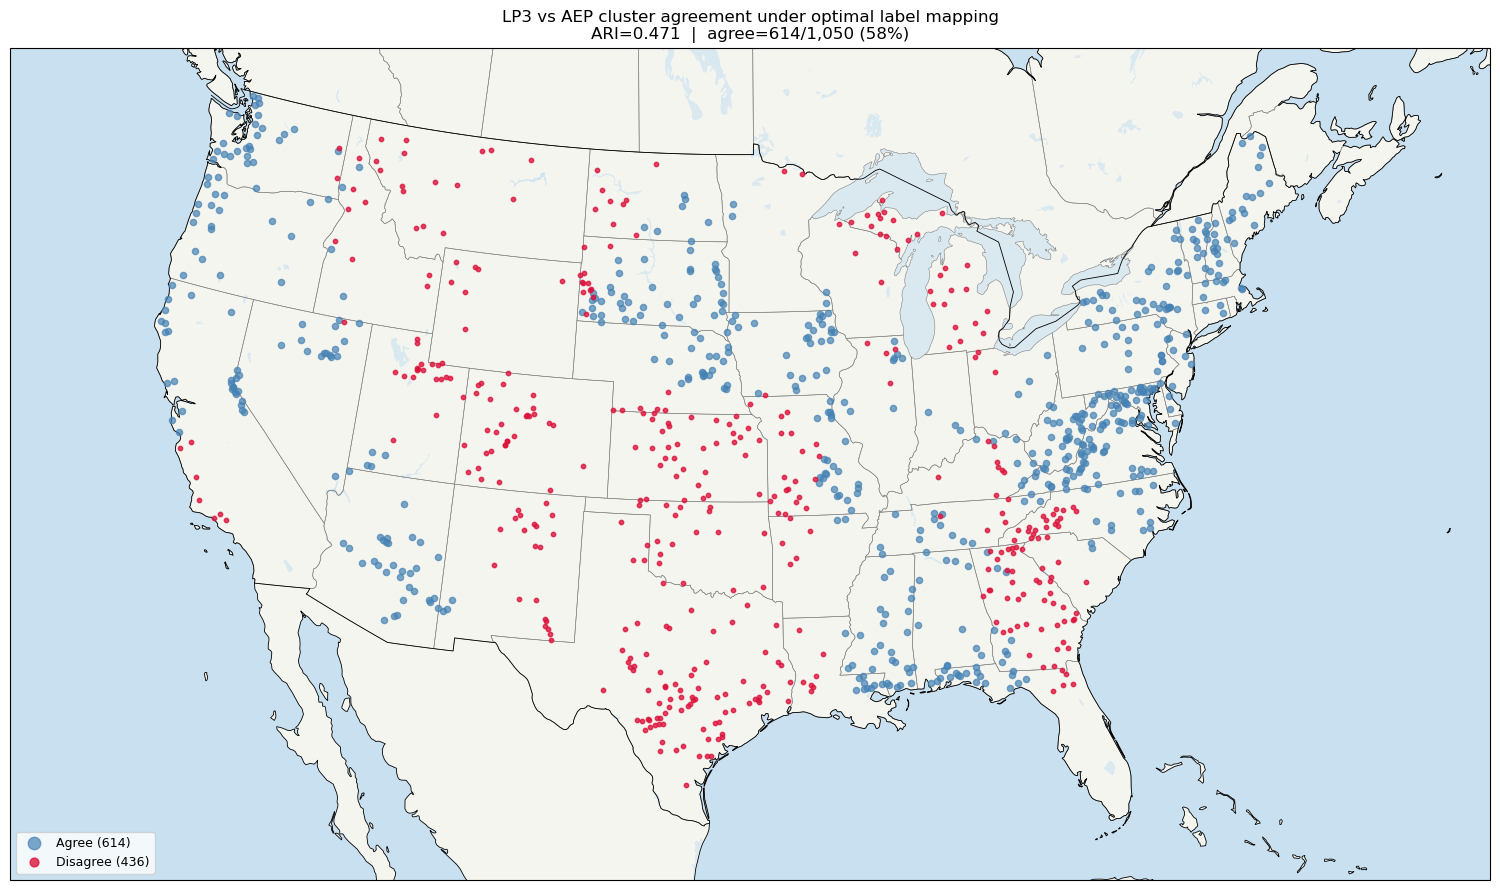

In [ ]:
from scipy.optimize import linear_sum_assignment

# Optimal LP3→AEP label alignment (maximise overlap)
row_idx, col_idx = linear_sum_assignment(-ct.values)
lp3_to_aep = {ct.index[r]: ct.columns[c] for r, c in zip(row_idx, col_idx)}

print("Optimal LP3 → AEP label mapping:")
for lp3, aep in sorted(lp3_to_aep.items()):
    n_agree = ct.loc[lp3, aep] if aep in ct.columns else 0
    n_total = ct.loc[lp3].sum()
    print(f"  LP3 C{lp3} → AEP C{aep}  ({n_agree:,}/{n_total:,} agree,  {100*n_agree/n_total:.0f}%)")

merged["cl_lp3_mapped"] = merged.cl_lp3.map(lp3_to_aep)
merged["agree"] = merged.cl_lp3_mapped == merged.cl_aep

n_agree = merged.agree.sum()
print(f"\nOverall agreement: {n_agree:,}/{len(merged):,}  ({100*n_agree/len(merged):.1f}%)")

# Pull coordinates for the shared sites from df1
coords_shared = df1[["site_no", "latitude", "longitude"]]
m_coords = merged.merge(coords_shared, on="site_no")

agree_df    = m_coords[m_coords.agree]
disagree_df = m_coords[~m_coords.agree]

fig = plt.figure(figsize=(16, 9))
ax  = make_conus_ax(fig, title=(
    f"LP3 vs AEP cluster agreement under optimal label mapping\n"
    f"ARI={ari:.3f}  |  agree={n_agree:,}/{len(merged):,} ({100*n_agree/len(merged):.0f}%)"
))

ax.scatter(
    agree_df.longitude, agree_df.latitude,
    s=20, color="steelblue", alpha=0.7,
    transform=ccrs.PlateCarree(), zorder=4,
    label=f"Agree ({len(agree_df):,})"
)
ax.scatter(
    disagree_df.longitude, disagree_df.latitude,
    s=10, color="crimson", alpha=0.8,
    transform=ccrs.PlateCarree(), zorder=5,
    label=f"Disagree ({len(disagree_df):,})"
)

ax.legend(markerscale=2, fontsize=9, loc="lower left", framealpha=0.8)
plt.tight_layout()
if SAVEFIG:
    plt.savefig(OUT_DIR / f"skater_agreement_k{K_NEIGHBORS}.png", dpi=300, bbox_inches="tight")
plt.show()

## Agreement map

Cluster labels are arbitrary, so "agreement" is defined via the **optimal LP3→AEP label mapping** found by the Hungarian algorithm on the contingency table.  Sites are then coloured by whether their assignments agree under that mapping.

## Cluster agreement: contingency table and Adjusted Rand Index

The **contingency table** counts how many of the shared sites land in each (LP3 cluster, AEP cluster) combination.  
The **Adjusted Rand Index** (ARI) summarises overall agreement as a single number: 0 = random, 1 = perfect, negative = worse than random.  
The two **normalised heatmaps** (row-normalised and column-normalised) reveal whether LP3 clusters map cleanly onto AEP clusters or whether they fragment.


ARI / NMI (scalar summary)

ARI > 0.5 → the two clusterings agree substantially on which sites belong together
ARI near 0 → the methods are capturing different structure
Row-normalised heatmap — each row sums to 1. A bright diagonal means LP3 cluster k maps cleanly to a single AEP cluster. Spread across columns means LP3 curve-shape doesn't predict threshold exceedance behaviour well.